Разведочный анализ (EDA)

**Цель:** понять структуру данных, найти аномалии, сформулировать первые гипотезы для дальнейшего анализа.

**Что будет сделано:**
1. Загрузка очищенного датасета `hotels_all.csv`.
2. Общая информация: строки, колонки, распределение по городам и сезонам.
3. Распределение цен, рейтингов, звёздности, расстояния до центра.
4. Сравнение базовых метрик по городам и сезонам.
5. Проверка пропусков в сегментах.
6. Сохранение графиков в `../visuals/`.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

# Настройка графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

PROCESSED_PATH = "../data/processed"
VISUALS_PATH = "../visuals"

df = pd.read_csv(f"{PROCESSED_PATH}/hotels_all.csv")
print(f"Загружено: {df.shape[0]} строк, {df.shape[1]} колонок")
df.head(3)

Загружено: 1110 строк, 58 колонок


,address,checkIn,checkOut,city,country,currency,distanceFromCenterKm,freeCancellation,hasBreakfast,hasSecureDeposit,hotelId,isGuruHotel,isSuperhost,kind,latitude,longitude,masterId,metroNearby,minPrice,minPricePerNight,name,nameEn,nearestSubway,nearestSubwayDistanceM,otaChainId,priceEur,priceRub,priceUsd,rates/0/currency,rates/0/freeCancellation,rates/0/freeCancellationBefore,rates/0/hasBreakfast,rates/0/mealType,rates/0/price,rates/0/priceEur,rates/0/pricePerNight,rates/0/priceRub,rates/0/priceUsd,rates/0/roomName,ratesCount,rating,ratingCount,regionId,regionName,roomsNumber,scrapedAt,starRating,tripadvisorRating,tripadvisorReviews,type,source_city,source_season,source_file,nights,price_per_night_calc,distance_category,rating_category,photo_count
0,"Samarskaya street, 1, Москва",2026-10-15,2026-10-25,Москва,Россия,RUB,3.249540,True,False,False,radisson_blu_olympiyskiy_hotel,True,False,Hotel,55.784706,37.626274,8869780,True,143000.0,14300,"Гостиница Radisson Blu Олимпийский, Москва","Radisson Blu Olympiyskiy Hotel, Moscow",Проспект Мира (Калужско-Рижская),548.0,18.0,1491.83,143000.0,1700.86,RUB,True,2026-10-14T21:00:00Z,False,nomeal,143000.0,1491.83,14300,143000.0,1700.86,Двухместный номер Стандартный с видом на город...,1,9.1,728.0,2395,Москва,379.0,2026-09-27 07:36:50.471,5.0,NaN,NaN,awarded-hotel,Москва,октябрь,moscow_october.xlsx,10,14300.0,2-5 км,9+,10
1,"150 Mira Prospect, Москва",2026-10-15,2026-10-25,Москва,Россия,RUB,7.581613,True,False,False,cosmos_hotel,True,False,Hotel,55.822060,37.647100,7466678,True,46200.0,4620,Cosmos Москва ВДНХ Отель,Cosmos Moscow VDNH Hotel,ВДНХ,384.0,873.0,481.97,46200.0,549.51,RUB,True,2026-10-14T21:00:00Z,False,nomeal,46200.0,481.97,4620,46200.0,549.51,Номер Стандарт,1,6.9,2533.0,2395,Москва,1644.0,2026-09-27 07:36:50.471,3.0,NaN,NaN,historic-hotel,Москва,октябрь,moscow_october.xlsx,10,4620.0,5-10 км,<7,10
2,"Ленинский проспект, д.158, Москва",2026-10-15,2026-10-25,Москва,Россия,RUB,14.356438,True,False,False,happy_home_apartment_hotel,True,False,Hotel,55.651367,37.482860,13647556,True,45600.0,4560,Апарт-отель Happy Home,Happy Home Apartment hotel,Тропарёво,892.0,NaN,475.72,45600.0,542.37,RUB,True,2026-10-14T12:00:00Z,False,nomeal,45600.0,475.72,4560,45600.0,542.37,Апартаменты Comfort c 1 комнатой (двуспальная ...,1,7.9,30.0,2395,Москва,25.0,2026-09-27 07:36:50.471,NaN,NaN,NaN,NaN,Москва,октябрь,moscow_october.xlsx,10,4560.0,10-20 км,7-8,10


In [5]:
print(f"Строк: {len(df)}")
print(f"Столбцов: {df.shape[1]}")

print(f"Города: {df['source_city'].value_counts().to_dict()}")
print(f"Сезоны: {df['source_season'].value_counts().to_dict()}")

print(f"Распределение по городам и сезонам:")
print(df.groupby(["source_city", "source_season"]).size())

Строк: 1110
Столбцов: 58
Города: {'Москва': 610, 'Сочи': 500}
Сезоны: {'январь': 600, 'октябрь': 510}
Распределение по городам и сезонам:
source_city  source_season
Москва       октябрь          260
             январь           350
Сочи         октябрь          250
             январь           250
dtype: int64


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1110 entries, 0 to 1109
Data columns (total 58 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   address                         1110 non-null   str    
 1   checkIn                         1110 non-null   str    
 2   checkOut                        1110 non-null   str    
 3   city                            1110 non-null   str    
 4   country                         1110 non-null   str    
 5   currency                        1110 non-null   str    
 6   distanceFromCenterKm            1110 non-null   float64
 7   freeCancellation                1110 non-null   bool   
 8   hasBreakfast                    1110 non-null   bool   
 9   hasSecureDeposit                1110 non-null   bool   
 10  hotelId                         1110 non-null   str    
 11  isGuruHotel                     1110 non-null   bool   
 12  isSuperhost                     1110 non-null

## 2. Распределение цен

In [8]:
print("Статистика по цене за ночь (price_per_night_calc):")
print(df["price_per_night_calc"].describe().round(0))

print("Статистика по цене за весь период (priceRub):")
print(df["priceRub"].describe().round(0))

Статистика по цене за ночь (price_per_night_calc):
count      1110.0
mean       7998.0
std        7190.0
min         800.0
25%        4000.0
50%        6132.0
75%        9564.0
max      111111.0
Name: price_per_night_calc, dtype: float64
Статистика по цене за весь период (priceRub):
count      1110.0
mean      64181.0
std       54582.0
min        8000.0
25%       33132.0
50%       51425.0
75%       75528.0
max      777777.0
Name: priceRub, dtype: float64


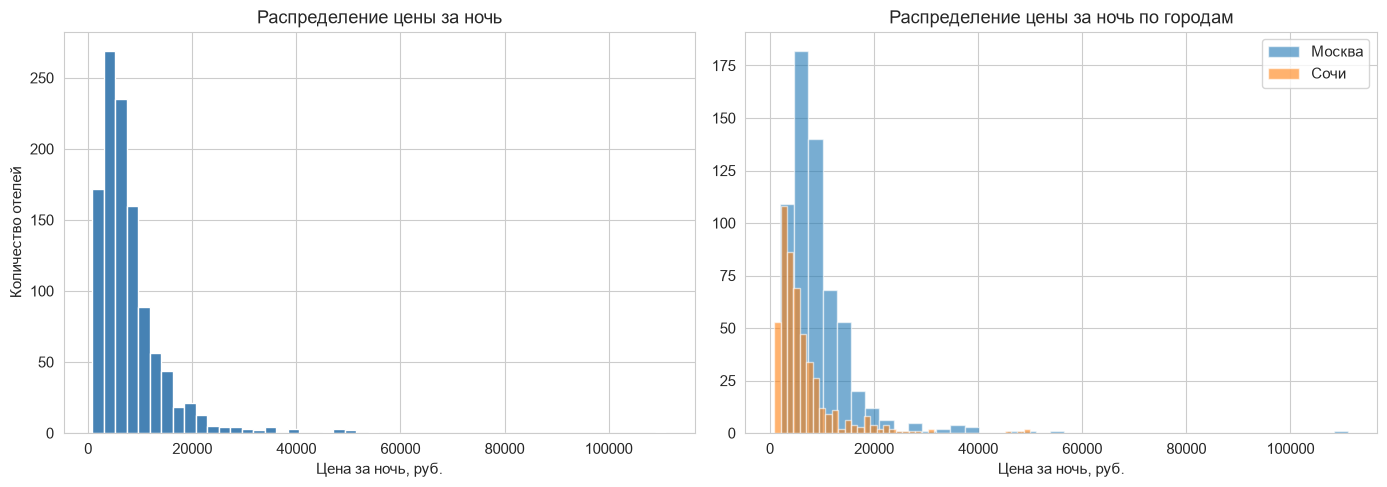

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["price_per_night_calc"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Распределение цены за ночь")
axes[0].set_xlabel("Цена за ночь, руб.")
axes[0].set_ylabel("Количество отелей")

for city in df["source_city"].unique():
    subset = df[df["source_city"] == city]["price_per_night_calc"]
    axes[1].hist(subset, bins=40, alpha=0.6, label=city)

axes[1].set_title("Распределение цены за ночь по городам")
axes[1].set_xlabel("Цена за ночь, руб.")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{VISUALS_PATH}/price_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

## 3. Boxplot: цены по городам и сезонам

Сравниваем медианы и разброс цен. Boxplot показывает медиану, квартили и выбросы.

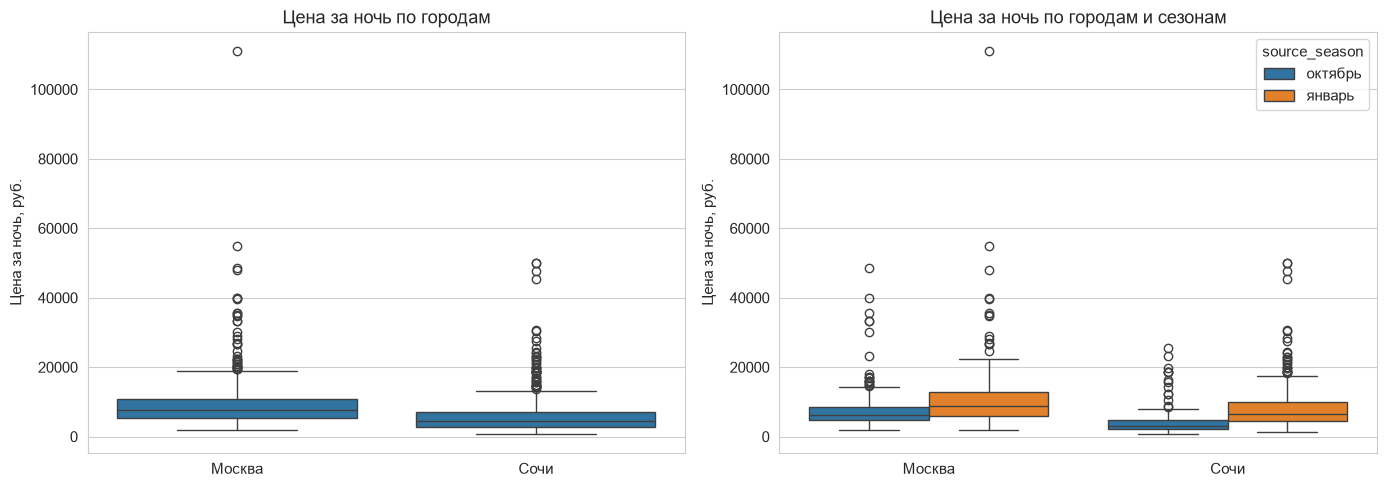

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#По городам
sns.boxplot(data=df, x="source_city", y="price_per_night_calc", ax=axes[0])
axes[0].set_title("Цена за ночь по городам")
axes[0].set_ylabel("Цена за ночь, руб.")
axes[0].set_xlabel("")

#По сезонам в разрезе городов
sns.boxplot(data=df, x="source_city", y="price_per_night_calc",
            hue="source_season", ax=axes[1])
axes[1].set_title("Цена за ночь по городам и сезонам")
axes[1].set_ylabel("Цена за ночь, руб.")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig(f"{VISUALS_PATH}/price_boxplot.png", dpi=100, bbox_inches="tight")
plt.show()

In [14]:
summary = df.groupby(["source_city", "source_season"])["price_per_night_calc"].agg(
    ["median", "mean", "count"]
).round(0)
print(summary)

for city in ["Москва", "Сочи"]:
    oct_med = df[(df["source_city"] == city) & (df["source_season"] == "октябрь")]["price_per_night_calc"].median()
    jan_med = df[(df["source_city"] == city) & (df["source_season"] == "январь")]["price_per_night_calc"].median()
    growth = (jan_med - oct_med) / oct_med * 100
    print(f"{city}: октябрь = {oct_med:.0f} руб., январь = {jan_med:.0f} руб., рост = {growth:+.1f}%")

                           median     mean  count
source_city source_season                        
Москва      октябрь        6332.0   7722.0    260
            январь         8695.0  10523.0    350
Сочи        октябрь        3149.0   4095.0    250
            январь         6466.0   8654.0    250
Москва: октябрь = 6332 руб., январь = 8695 руб., рост = +37.3%
Сочи: октябрь = 3149 руб., январь = 6466 руб., рост = +105.3%


## Выводы: сезонность цен по городам

Boxplot сравнивает распределение цены за ночь между городами (Москва и Сочи) и сезонами (октябрь и январь). Показывает медиану, межквартильный размах и выбросы.

### Что видно на графике

**1. Москва: заметный рост цен в январе.**
Медиана цены за ночь выросла с **6 332 руб.** в октябре до **8 695 руб.** в январе. Рост составил **+37.3%**. Это объясняется новогодними праздниками и школьными каникулами — в столицу едет больше туристов.

**2. Сочи: очень сильный рост цен в январе.**
Медиана октября - **3 149 руб.**, января - **6 466 руб.**, рост **+105.3%** — более чем в 2 раза. Гипотеза о том, что курортный город сильнее реагирует на сезон, **полностью подтвердилась**. Визуально ящики казались похожими, НО из-за большого числа выбросов (до 50-100 тыс. руб.) масштаб оси Y раздут, и основная масса данных «сжата» в нижней части. Реальную картину дают только точные медианы.

**3. Разброс цен.**
В обеих группах есть выбросы - отели с ценой до **50 тыс. руб.** за ночь. В Москве один экстремальный выброс - **>100 тыс. руб.**, что требует отдельной проверки (возможно, ошибка парсинга или действительно премиум-люкс).

### Ключевой инсайт

> **Курортный город реагирует на новогодние праздники в 3 раза сильнее столицы.** Медианная цена за ночь в Сочи выросла более чем в 2 раза (с 3 149 руб. до 6 466 руб.), тогда как в Москве - только на 37% (с 6 332 руб. до 8 695 руб.).
>
> При этом в абсолютных цифрах в январе Сочи (6 466 руб.) почти догоняет Москву (8 695 руб.), хотя в октябре разрыв был двукратным. Бархатный сезон в Сочи - самое дешёвое время для поездки, а Новый год — самое дорогое.

### Ограничения

- Выборка - топ отелей по выдаче Ostrovok, а не весь рынок.
- Январь включает только 7 ночей против 10 в октябре - для сравнения используется цена за ночь.
- Не учитываются закрытые на сезон отели, которые могли бы повлиять на медиану.
- Из-за большого числа выбросов среднее сильно выше медианы - для выводов используется медиана, она устойчивее.

## 4. Базовые метрики по городам и сезонам

In [18]:
summary = df.groupby(["source_city", "source_season"]).agg(
    hotels=("hotelId", "count"),
    median_price=("price_per_night_calc", "median"),
    mean_price=("price_per_night_calc", "mean"),
    min_price=("price_per_night_calc", "min"),
    max_price=("price_per_night_calc", "max"),
    mean_rating=("rating", "mean"),
    mean_distance=("distanceFromCenterKm", "mean"),
).round(1)
summary

hotels  median_price  mean_price  min_price  max_price  mean_rating  mean_distance
source_city source_season                                                                                    
Москва      октябрь           260        6332.0      7722.4     1916.0    48500.0          8.7            6.0
            январь            350        8695.3     10522.7     1931.0   111111.0          8.6            6.7
Сочи        октябрь           250        3149.4      4095.2      800.0    25500.0          8.6           16.4
            январь            250        6466.0      8653.9     1206.9    50000.0          8.7           15.8

## 5. Рейтинг и категория отеля

Разбираем два связанных показателя качества:
- **Рейтинг** - оценка гостей на Ostrovok.
- **Количество звёзд** (`starRating`) - официальная категория отеля.

Смотрим каждое распределение отдельно, а затем — как они связаны между собой.

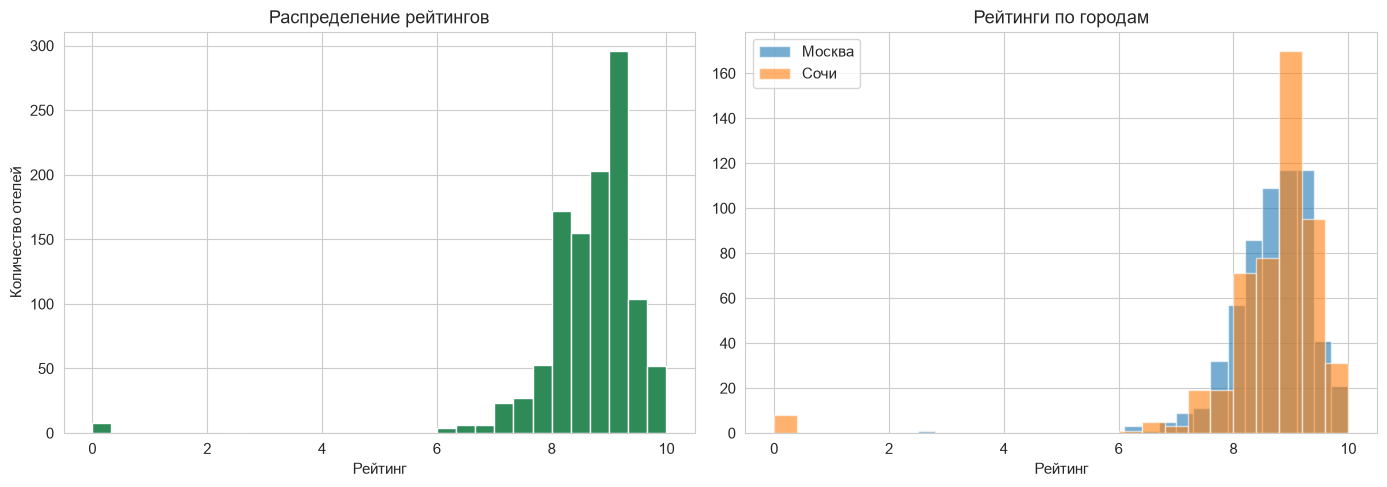

Статистика по рейтингу:
count    1110.00
mean        8.66
std         1.00
min         0.00
25%         8.30
50%         8.80
75%         9.20
max        10.00
Name: rating, dtype: float64


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение рейтингов
axes[0].hist(df["rating"], bins=30, color="seagreen", edgecolor="white")
axes[0].set_title("Распределение рейтингов")
axes[0].set_xlabel("Рейтинг")
axes[0].set_ylabel("Количество отелей")

# По городам
for city in df["source_city"].unique():
    subset = df[df["source_city"] == city]["rating"]
    axes[1].hist(subset, bins=25, alpha=0.6, label=city)

axes[1].set_title("Рейтинги по городам")
axes[1].set_xlabel("Рейтинг")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{VISUALS_PATH}/rating_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

print("Статистика по рейтингу:")
print(df["rating"].describe().round(2))

### Вывод по рейтингам

Рейтинги отелей распределены в узком диапазоне: медиана **8.8**, среднее **8.66**, межквартильный размах **8.3-9.2**. Это говорит о том, что парсер собрал преимущественно качественные отели из топа выдачи Ostrovok - с рейтингом ниже 7 в выборке почти нет.

Распределение рейтингов между Москвой и Сочи практически не отличается.

Распределение по количеству звёзд:
starRating
1.0      4
2.0     22
3.0    252
4.0    242
5.0     83
Name: count, dtype: int64
Без категории: 507 отелей (45.7%)


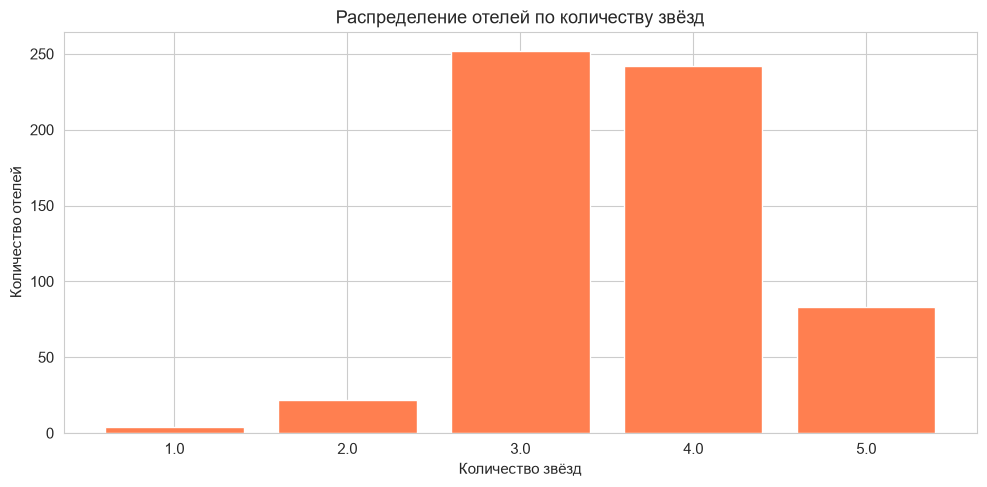

In [29]:
print("Распределение по количеству звёзд:")
print(df["starRating"].value_counts().sort_index())

print(f"Без категории: {df['starRating'].isnull().sum()} отелей ({df['starRating'].isnull().mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
stars_counts = df["starRating"].value_counts().sort_index()
ax.bar(stars_counts.index.astype(str), stars_counts.values, color="coral", edgecolor="white")
ax.set_title("Распределение отелей по количеству звёзд")
ax.set_xlabel("Количество звёзд")
ax.set_ylabel("Количество отелей")
plt.tight_layout()
plt.savefig(f"{VISUALS_PATH}/stars_distribution.png", dpi=100, bbox_inches="tight")
plt.show()


### Вывод по количеству звёзд

**507 отелей (45.7%) — без категории**: это апартаменты, хостелы и мини-отели. Среди категорийных преобладают **3★ (252)** и **4★ (242)**, пятизвёздочных меньше - **83**. Отелей с 1★ и 2★ единицы (4 и 22).

Для сравнения сегментов подходят 3★ и 4★ — выборки сопоставимы. По 5★ выводы возможны, но менее надёжны. По 1★ и 2★ — данных недостаточно.

## 6. Расстояние от центра

Смотрим, как отели распределены по удалённости от центра. Это важно для анализа ценообразования - близость к центру может влиять на цену.

Распределение по категориям расстояния:
distance_category
0-2 км      252
10-20 км    161
2-5 км      268
20+ км      268
5-10 км     161
Name: count, dtype: int64
Статистика по distanceFromCenterKm:
count    1110.00
mean       10.78
std        10.57
min         0.16
25%         2.22
50%         5.61
75%        19.27
max        53.92
Name: distanceFromCenterKm, dtype: float64


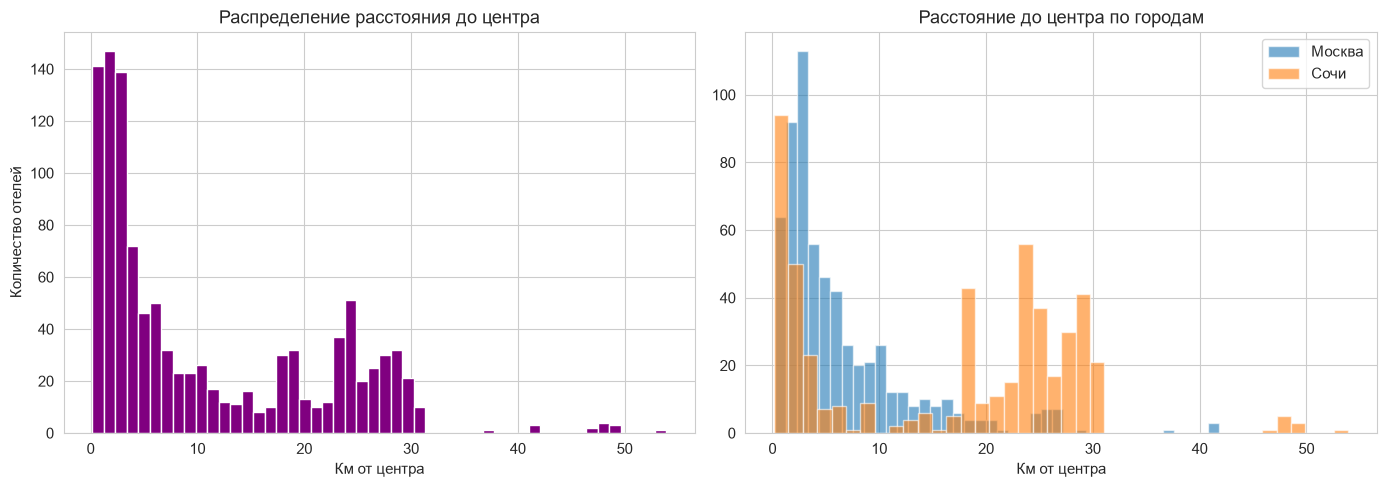

In [30]:
print("Распределение по категориям расстояния:")
print(df["distance_category"].value_counts().sort_index())

print(f"Статистика по distanceFromCenterKm:")
print(df["distanceFromCenterKm"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Общее распределение
axes[0].hist(df["distanceFromCenterKm"], bins=50, color="purple", edgecolor="white")
axes[0].set_title("Распределение расстояния до центра")
axes[0].set_xlabel("Км от центра")
axes[0].set_ylabel("Количество отелей")

# По городам
for city in df["source_city"].unique():
    subset = df[df["source_city"] == city]["distanceFromCenterKm"]
    axes[1].hist(subset, bins=40, alpha=0.6, label=city)

axes[1].set_title("Расстояние до центра по городам")
axes[1].set_xlabel("Км от центра")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{VISUALS_PATH}/distance_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

### Вывод по расстоянию от центра

Распределение двугорбое: 47% отелей - близко к центру (0-5 км), но ещё 39% - далеко (10+ км). Середина (5-10 км) почти пустая. Среднее (10.8 км) сильно выше медианы (5.6 км) — из-за длинного хвоста до 54 км.

Причина - разные города: Москва компактная, а Сочи вытянут вдоль побережья на десятки километров. При сравнении цены и расстояния между городами это надо учитывать: в Сочи расстояние от центра менее значимо, чем близость к морю.

## 7. Корреляционный анализ

Корреляционная матрица:
                      price_per_night_calc  rating  starRating  distanceFromCenterKm  ratingCount  photo_count
price_per_night_calc                  1.00    0.14        0.59                 -0.14         0.24         0.08
rating                                0.14    1.00        0.39                 -0.03        -0.02         0.06
starRating                            0.59    0.39        1.00                 -0.11         0.21         0.11
distanceFromCenterKm                 -0.14   -0.03       -0.11                  1.00        -0.12        -0.04
ratingCount                           0.24   -0.02        0.21                 -0.12         1.00         0.08
photo_count                           0.08    0.06        0.11                 -0.04         0.08         1.00


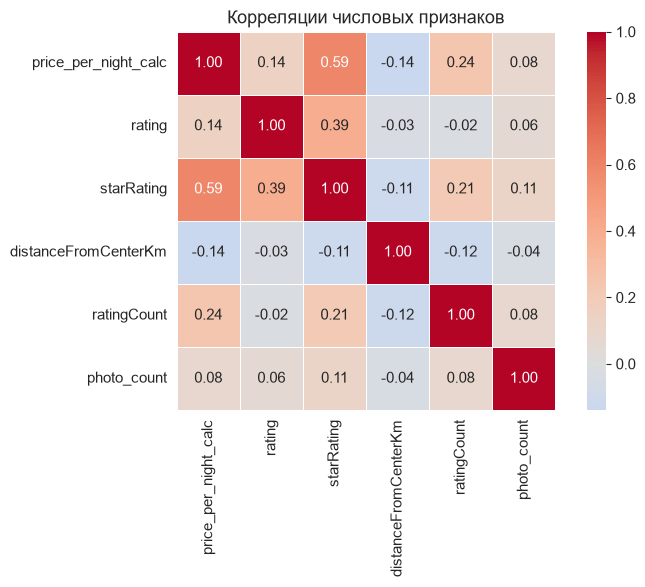

In [31]:
numeric_cols = [
    "price_per_night_calc", "rating", "starRating",
    "distanceFromCenterKm", "ratingCount", "photo_count"
]
corr_cols = [c for c in numeric_cols if c in df.columns]

corr_matrix = df[corr_cols].corr().round(2)
print("Корреляционная матрица:")
print(corr_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Корреляции числовых признаков")
plt.tight_layout()
plt.savefig(f"{VISUALS_PATH}/correlations.png", dpi=100, bbox_inches="tight")
plt.show()

### Вывод по корреляционной матрице

**Сильные связи (|r| > 0.5):**
- **Цена - количество звёзд: 0.59** - единственная заметная связь. Чем выше категория, тем дороже отель.

**Умеренные связи (0.3-0.5):**
- **Рейтинг - количество звёзд: 0.39** - категорийные отели получают более высокие оценки гостей, но связь не линейная.

**Слабые связи (0.1-0.3):**
- **Цена - рейтинг: 0.14** - высокий рейтинг не гарантирует высокую цену.
- **Цена - число отзывов: 0.24** - популярные отели чуть дороже.
- **Цена - расстояние до центра: −0.14** - ближе к центру - немного дороже, но слабо.

**Почти нет связи (< 0.1):**
- **Цена - количество фото: 0.08** - число фотографий не влияет на цену.

**Главный вывод:** цена отеля определяется прежде всего **категорией (звёздами)**. Рейтинг, расстояние до центра и число фото на цену почти не влияют. Это значит, что при анализе ценообразования ключевой признак - `starRating`, а не `rating`.


## 8. Пропуски в сегментах

In [33]:
no_stars = df[df["starRating"].isnull()]
print("Отели без категории — распределение по типу:")
print(no_stars["kind"].value_counts())

print(f"Без категории: {len(no_stars)}")
print(f"С категорией: {len(df) - len(no_stars)}")

no_ta = df[df["tripadvisorRating"].isnull()]
print(f"Без Tripadvisor: {len(no_ta)} ({len(no_ta)/len(df)*100:.1f}%)")

no_metro = df[df["metroNearby"].isnull()]
print(f"Без информации о метро: {len(no_metro)} ({len(no_metro)/len(df)*100:.1f}%)")

Отели без категории — распределение по типу:
kind
Hotel                  178
Guesthouse             136
Apartment              117
Hostel                  27
Mini-hotel              21
Aparthotel              20
Resort                   4
Boutique_and_Design      2
Cottages_and_Houses      2
Name: count, dtype: int64

Без категории: 507
С категорией: 603

Без Tripadvisor: 651 (58.6%)

Без информации о метро: 551 (49.6%)


### Вывод по пропускам

**Отели без категории (507)** - это не только хостелы и апартаменты. Даже среди обычных Hotel - 178 без звёзд, плюс Guesthouse (136) и Apartment (117). То есть отсутствие категории это не признак «дешёвого» типа жилья, а просто особенность заполнения карточки на Ostrovok.

**Без Tripadvisor - 58.6%** отелей. Это нормально: не все объекты размещения есть на Tripadvisor, особенно малые и региональные.

**Без информации о метро - 49.6%.** В Москве метро есть почти везде, а в Сочи его нет как такового - отсюда такая доля пропусков.

## Итоги разведочного анализа

### Структура данных

1110 отелей из Ostrovok: Москва и Сочи, октябрь 2026 и январь 2027. Каждая группа - 250-350 отелей. Данные включают цены, рейтинги, категорию, расстояние от центра, условия тарифов, координаты.

### Ключевые инсайты

**1. Сезонность выражена по-разному в двух городах.**
В Москве медианная цена за ночь выросла с 6 332 руб. в октябре до 8 695 руб. в январе (**+37%**). В Сочи - с 3 149 руб. до 6 466 руб. (**+105%**). Курортный город реагирует на новогодние праздники в 3 раза сильнее столицы. При этом в абсолютных цифрах Сочи в январе почти догоняет Москву, хотя в октябре был вдвое дешевле.

**2. Цена определяется категорией, а не рейтингом.**
Корреляция "цена - звёзды" - **0.59** (единственная сильная связь). Корреляция "цена - рейтинг" - **0.14** (слабая). Дорогой отель не равен отелю с высоким рейтингом. При анализе ценообразования ключевой признак - `starRating`.

**3. Рейтинги одинаково высокие везде.**
Медиана 8.8, среднее 8.66, межквартильный размах 8.3-9.2. Разницы между Москвой и Сочи нет. Это следствие того, что парсер собрал топ выдачи - отелей с низким рейтингом в выборке почти нет.

**4. Почти половина отелей - без категории.**
507 из 1110 (45.7%). Это не только хостелы: среди них 178 обычных отелей, 136 гостевых домов, 117 апартаментов. Отсутствие звёзд - особенность карточки, а не признак "дешёвого" типа жилья.

**5. Расположение влияет на цену слабо.**
Корреляция "цена - расстояние от центра" - **-0.14**. Ближе к центру - чуть дороже, но эффект небольшой. В Сочи расстояние от центра вообще плохой ориентир: город вытянут вдоль побережья на 50+ км, важнее близость к морю.

### Вывод

- **Сочи** - ярко выраженный сезонный рынок: если стартап запускает продукт по этому направлению, надо готовиться к пикам спроса в новогодние праздники и просадкам в межсезонье.
- **Москва** - более ровный рынок с умеренной сезонностью.
- **Ценообразование** привязано к категории отеля, а не к оценке гостей. Это значит, что для рекомендаций по ценам нужно опираться на звёзды, а не на рейтинг.
